# FairDerm: Second Seed Run (Seed 123)

This notebook runs all experiments with seed=123 to complement the existing seed=42 results.

**Purpose:** Enable statistical analysis with mean ± std across 2 seeds.

**Methods:**
1. Baseline
2. Mixup
3. Reweighted
4. Focal Loss
5. Proposed
6. **Proposed_GroupAug** (NEW: Group-aware augmentation for minorities)

## 1. Setup

In [1]:
# Mount Google Drive (for Colab)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install dependencies
!pip install timm --quiet

In [3]:
# Add fairderm package to path (if running from Colab)
import sys
sys.path.insert(0, '/content/drive/MyDrive/thesis/code')

# Import standard libraries
import torch
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Import custom fairderm modules
from fairderm import (
    SkinLesionDataset,
    create_model,
    SkinToneAdaptiveSampler,
    get_class_weights,
    get_train_transforms,
    get_eval_transforms,
    run_experiment,
    save_experiment_results,
)
from fairderm.configs import (
    get_baseline_config,
    get_mixup_config,
    get_reweighted_config,
    get_focal_config,
    get_proposed_config,
    get_proposed_group_aug_config,  # NEW: Group-aware augmentation
)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [4]:
import os

# =============================================
# CONFIGURATION - SEED 123
# =============================================
SEED = 123  # NEW SEED (different from original 42)

PROJECT_DIR = '/content/drive/MyDrive/thesis'
DATA_DIR = os.path.join(PROJECT_DIR, 'data')
RESULTS_DIR = os.path.join(PROJECT_DIR, 'results')

CSV_PATH = os.path.join(DATA_DIR, 'fitzpatrick17k_processed.csv')

os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Running experiments with SEED = {SEED}")
print(f"Data directory: {DATA_DIR}")
print(f"Results directory: {RESULTS_DIR}")

Running experiments with SEED = 123
Data directory: /content/drive/MyDrive/thesis/data
Results directory: /content/drive/MyDrive/thesis/results


## 2. Load and Prepare Data

**Important:** We use the SAME random_state=42 for train/val split to ensure identical data splits across seeds. Only the model training uses the new seed.

In [5]:
# Load the processed CSV
df = pd.read_csv(CSV_PATH)

# Show dataset summary
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
print(f"\nTotal samples: {len(df)}")
print("\nSkin tone group distribution:")
print(df['tone_group'].value_counts())

DATASET SUMMARY

Total samples: 4491

Skin tone group distribution:
tone_group
Light      2308
Medium     1599
Dark        409
Unknown     175
Name: count, dtype: int64


In [6]:
# Create stratified train/val split
# IMPORTANT: Use random_state=42 (same as original) to get IDENTICAL splits
# Only the model training will use the new seed (123)
df['stratify_key'] = df['label'].astype(str) + '_' + df['tone_group']

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,  # KEEP AS 42 for identical splits!
    stratify=df['stratify_key']
)

train_df = train_df.drop('stratify_key', axis=1).reset_index(drop=True)
val_df = val_df.drop('stratify_key', axis=1).reset_index(drop=True)

print(f"Train set: {len(train_df)} samples")
print(f"Val set: {len(val_df)} samples")
print("\n(Using same train/val split as seed=42 run)")

Train set: 3592 samples
Val set: 899 samples

(Using same train/val split as seed=42 run)


In [7]:
# Create datasets with transforms
train_transform = get_train_transforms()
eval_transform = get_eval_transforms()

train_dataset = SkinLesionDataset(train_df, transform=train_transform, return_group=True)
val_dataset = SkinLesionDataset(val_df, transform=eval_transform, return_group=True)

print(f"Train dataset: {len(train_dataset)} samples")
print(f"Val dataset: {len(val_dataset)} samples")

Train dataset: 3592 samples
Val dataset: 899 samples


In [8]:
# Compute class weights for reweighted baseline
class_weights = get_class_weights(train_df, label_col='label_num')
print(f"Class weights: {class_weights}")

Class weights: tensor([1.0073, 0.9928])


In [9]:
# Store all results
all_results = {}

## 3. Run All Experiments with Seed 123

### 3.1 Baseline

In [10]:
config = get_baseline_config()
results = run_experiment(train_dataset, val_dataset, config, seed=SEED, device=device)
all_results[f'baseline_seed{SEED}'] = results

# Save model
save_experiment_results(results, f'baseline_seed{SEED}', RESULTS_DIR)


Experiment: Baseline (seed=123)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]


Starting training for 50 epochs...
Mixup: No
Adaptive Sampling: No
------------------------------------------------------------

Epoch 1/50


Validating: 100%|██████████| 29/29 [03:50<00:00,  7.95s/it]

...

Train Loss: 0.1028 | Train Acc: 0.9635
Val Loss: 0.5486 | Val Acc: 0.8498

Epoch 13/50



Validating: 100%|██████████| 29/29 [00:04<00:00,  6.99it/s]


Train Loss: 0.0929 | Train Acc: 0.9621
Val Loss: 0.5470 | Val Acc: 0.8487

Early stopping at epoch 13

Loaded best model checkpoint


Validating: 100%|██████████| 29/29 [00:08<00:00,  3.36it/s]



Baseline Results:
  Accuracy: 0.8187
  Balanced Accuracy: 0.8188
  ROC-AUC: 0.8936

FAIRNESS EVALUATION REPORT

Per-Group True Positive Rates (Sensitivity):
  Light: 0.7908 (n=462)
  Medium: 0.8146 (n=320)
  Dark: 0.7317 (n=82)
  -> Equal Opportunity Gap: 0.0829

Per-Group False Positive Rates:
  Light: 0.1928
  Medium: 0.1183
  Dark: 0.1463
  -> Equalized Odds Gap: 0.0829

Per-Group F1 Scores:
  Light: 0.8025
  Medium: 0.8367
  Dark: 0.7792
  -> Inter-group F1 Gap: 0.0575

Results saved to /content/drive/MyDrive/thesis/results/baseline_seed123


### 3.2 Mixup

In [11]:
config = get_mixup_config()
results = run_experiment(train_dataset, val_dataset, config, seed=SEED, device=device)
all_results[f'mixup_seed{SEED}'] = results

save_experiment_results(results, f'mixup_seed{SEED}', RESULTS_DIR)


Experiment: Mixup (seed=123)

Starting training for 50 epochs...
Mixup: Yes
Adaptive Sampling: No
------------------------------------------------------------

Epoch 1/50


Validating: 100%|██████████| 29/29 [00:04<00:00,  6.94it/s]

Train Loss: 0.6212 | Train Acc: 0.6548
Val Loss: 0.5255 | Val Acc: 0.7386

Epoch 2/50



Validating: 100%|██████████| 29/29 [00:04<00:00,  7.01it/s]

Train Loss: 0.5383 | Train Acc: 0.7303
Val Loss: 0.4638 | Val Acc: 0.8076

Epoch 3/50


...

Train Loss: 0.2780 | Train Acc: 0.8966
Val Loss: 0.3626 | Val Acc: 0.8598

Epoch 36/50



Validating: 100%|██████████| 29/29 [00:04<00:00,  7.04it/s]


Train Loss: 0.2509 | Train Acc: 0.9058
Val Loss: 0.3669 | Val Acc: 0.8632

Early stopping at epoch 36

Loaded best model checkpoint


Validating: 100%|██████████| 29/29 [00:08<00:00,  3.42it/s]



Mixup Results:
  Accuracy: 0.8621
  Balanced Accuracy: 0.8622
  ROC-AUC: 0.9238

FAIRNESS EVALUATION REPORT

Per-Group True Positive Rates (Sensitivity):
  Light: 0.8326 (n=462)
  Medium: 0.8477 (n=320)
  Dark: 0.7805 (n=82)
  -> Equal Opportunity Gap: 0.0672

Per-Group False Positive Rates:
  Light: 0.1345
  Medium: 0.0769
  Dark: 0.0976
  -> Equalized Odds Gap: 0.0672

Per-Group F1 Scores:
  Light: 0.8504
  Medium: 0.8767
  Dark: 0.8312
  -> Inter-group F1 Gap: 0.0455

Results saved to /content/drive/MyDrive/thesis/results/mixup_seed123


### 3.3 Reweighted

In [12]:
config = get_reweighted_config(class_weights, device=device)
results = run_experiment(train_dataset, val_dataset, config, seed=SEED, device=device)
all_results[f'reweighted_seed{SEED}'] = results

save_experiment_results(results, f'reweighted_seed{SEED}', RESULTS_DIR)


Experiment: Reweighted (seed=123)

Starting training for 50 epochs...
Mixup: No
Adaptive Sampling: No
------------------------------------------------------------

Epoch 1/50


Validating: 100%|██████████| 29/29 [00:04<00:00,  6.82it/s]

Train Loss: 0.5869 | Train Acc: 0.6940
Val Loss: 0.5020 | Val Acc: 0.7586

Epoch 2/50



Validating: 100%|██████████| 29/29 [00:04<00:00,  6.85it/s]

Train Loss: 0.4508 | Train Acc: 0.7934
Val Loss: 0.4314 | Val Acc: 0.8042

Epoch 3/50


...

Train Loss: 0.1049 | Train Acc: 0.9630
Val Loss: 0.5426 | Val Acc: 0.8476

Epoch 13/50



Validating: 100%|██████████| 29/29 [00:04<00:00,  6.97it/s]


Train Loss: 0.0863 | Train Acc: 0.9658
Val Loss: 0.5699 | Val Acc: 0.8476

Early stopping at epoch 13

Loaded best model checkpoint


Validating: 100%|██████████| 29/29 [00:08<00:00,  3.39it/s]



Reweighted Results:
  Accuracy: 0.8176
  Balanced Accuracy: 0.8177
  ROC-AUC: 0.8939

FAIRNESS EVALUATION REPORT

Per-Group True Positive Rates (Sensitivity):
  Light: 0.7908 (n=462)
  Medium: 0.8146 (n=320)
  Dark: 0.7317 (n=82)
  -> Equal Opportunity Gap: 0.0829

Per-Group False Positive Rates:
  Light: 0.1928
  Medium: 0.1183
  Dark: 0.1463
  -> Equalized Odds Gap: 0.0829

Per-Group F1 Scores:
  Light: 0.8025
  Medium: 0.8367
  Dark: 0.7792
  -> Inter-group F1 Gap: 0.0575

Results saved to /content/drive/MyDrive/thesis/results/reweighted_seed123


### 3.4 Focal Loss

In [13]:
config = get_focal_config()
results = run_experiment(train_dataset, val_dataset, config, seed=SEED, device=device)
all_results[f'focalloss_seed{SEED}'] = results

save_experiment_results(results, f'focalloss_seed{SEED}', RESULTS_DIR)


Experiment: FocalLoss (seed=123)

Starting training for 50 epochs...
Mixup: No
Adaptive Sampling: No
------------------------------------------------------------

Epoch 1/50


Validating: 100%|██████████| 29/29 [00:04<00:00,  7.01it/s]

Train Loss: 0.1491 | Train Acc: 0.6946
Val Loss: 0.1287 | Val Acc: 0.7709

Epoch 2/50



Validating: 100%|██████████| 29/29 [00:04<00:00,  7.15it/s]

Train Loss: 0.1201 | Train Acc: 0.7840
Val Loss: 0.1176 | Val Acc: 0.7798

Epoch 3/50


...

Train Loss: 0.0323 | Train Acc: 0.9602
Val Loss: 0.1644 | Val Acc: 0.8432

Epoch 13/50



Validating: 100%|██████████| 29/29 [00:04<00:00,  7.07it/s]


Train Loss: 0.0270 | Train Acc: 0.9591
Val Loss: 0.1709 | Val Acc: 0.8443

Early stopping at epoch 13

Loaded best model checkpoint


Validating: 100%|██████████| 29/29 [00:08<00:00,  3.25it/s]



FocalLoss Results:
  Accuracy: 0.8131
  Balanced Accuracy: 0.8131
  ROC-AUC: 0.8913

FAIRNESS EVALUATION REPORT

Per-Group True Positive Rates (Sensitivity):
  Light: 0.8159 (n=462)
  Medium: 0.8278 (n=320)
  Dark: 0.7317 (n=82)
  -> Equal Opportunity Gap: 0.0961

Per-Group False Positive Rates:
  Light: 0.2242
  Medium: 0.1479
  Dark: 0.1951
  -> Equalized Odds Gap: 0.0961

Per-Group F1 Scores:
  Light: 0.8058
  Medium: 0.8306
  Dark: 0.7595
  -> Inter-group F1 Gap: 0.0711

Results saved to /content/drive/MyDrive/thesis/results/focalloss_seed123


### 3.5 Proposed


Experiment: Proposed (seed=123)
Adaptive Sampler initialized
  Group sizes: {'Light': 1846, 'Medium': 1279, 'Dark': 327}
  Size weights: {'Light': 0.7182944072173485, 'Medium': 0.9286569033481047, 'Dark': 2.4125773474749472}
  Min prob floor: 0.1
  Alpha (loss vs size): 0.5

Starting training for 50 epochs...
Mixup: Yes
Adaptive Sampling: Yes
------------------------------------------------------------

Epoch 1/50


Training:   1%|          | 1/113 [00:00<01:24,  1.32it/s, loss=0.7102, acc=52.51%]

  Adaptive sampler warmup complete - all groups observed


Validating: 100%|██████████| 29/29 [00:04<00:00,  6.98it/s]


Train Loss: 0.6016 | Train Acc: 0.6678
Val Loss: 0.5226 | Val Acc: 0.7430
Sampling: Light=0.27, Medium=0.28, Dark=0.45

Epoch 2/50


...

Train Loss: 0.2467 | Train Acc: 0.9105
Val Loss: 0.3832 | Val Acc: 0.8576
Sampling: Light=0.30, Medium=0.27, Dark=0.43

Epoch 31/50


Validating: 100%|██████████| 29/29 [00:04<00:00,  6.94it/s]


Train Loss: 0.2762 | Train Acc: 0.8931
Val Loss: 0.3771 | Val Acc: 0.8476
Sampling: Light=0.28, Medium=0.28, Dark=0.44

Early stopping at epoch 31

Loaded best model checkpoint


Validating: 100%|██████████| 29/29 [00:08<00:00,  3.35it/s]



Proposed Results:
  Accuracy: 0.8654
  Balanced Accuracy: 0.8654
  ROC-AUC: 0.9237

FAIRNESS EVALUATION REPORT

Per-Group True Positive Rates (Sensitivity):
  Light: 0.8619 (n=462)
  Medium: 0.8808 (n=320)
  Dark: 0.8293 (n=82)
  -> Equal Opportunity Gap: 0.0515

Per-Group False Positive Rates:
  Light: 0.1839
  Medium: 0.0947
  Dark: 0.0732
  -> Equalized Odds Gap: 0.1107

Per-Group F1 Scores:
  Light: 0.8477
  Medium: 0.8867
  Dark: 0.8718
  -> Inter-group F1 Gap: 0.0389

Results saved to /content/drive/MyDrive/thesis/results/proposed_seed123


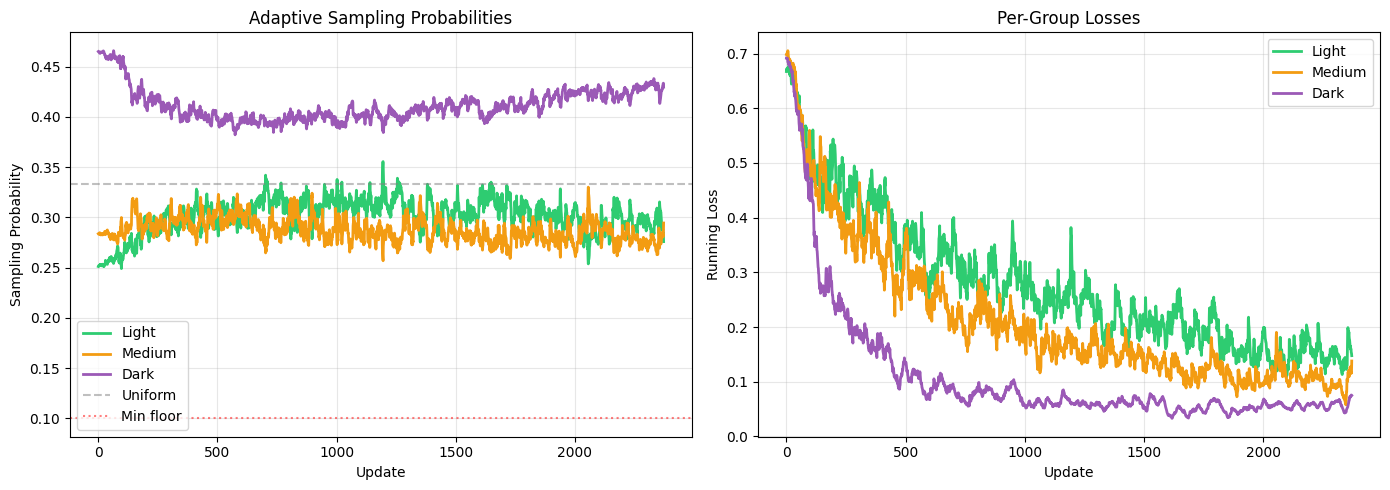

In [14]:
config = get_proposed_config()
results = run_experiment(train_dataset, val_dataset, config, seed=SEED, device=device)
all_results[f'proposed_seed{SEED}'] = results

save_experiment_results(results, f'proposed_seed{SEED}', RESULTS_DIR)

# Plot adaptive sampler history
if results['adaptive_sampler']:
    results['adaptive_sampler'].plot_history(
        save_path=os.path.join(RESULTS_DIR, f'proposed_seed{SEED}', 'sampler_history.png')
    )

### 3.6 Proposed with Group-Aware Augmentation

This extends the Proposed method with **group-aware augmentation**:
- **Light (majority)**: Standard augmentation (rotation ±20°, color jitter 0.2)
- **Medium/Dark (minority)**: Enhanced geometric augmentation (rotation ±180°, translation, scale) but **reduced color augmentation** to preserve diagnostic features

Based on clinical validation using ABCDE criteria - color is diagnostic in dermatology.

Using GROUP-AWARE augmentation:
  - Light (majority): Standard augmentation
  - Medium/Dark (minority): Enhanced geometric, reduced color augmentation

Experiment: Proposed_GroupAug (seed=123)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

Adaptive Sampler initialized
  Group sizes: {'Light': 1846, 'Medium': 1279, 'Dark': 327}
  Size weights: {'Light': 0.7182944072173485, 'Medium': 0.9286569033481047, 'Dark': 2.4125773474749472}
  Min prob floor: 0.1
  Alpha (loss vs size): 0.5

Starting training for 50 epochs...
Mixup: Yes
Adaptive Sampling: Yes
------------------------------------------------------------

Epoch 1/50


Training:   0%|          | 0/113 [00:00<?, ?it/s]

...

Train Loss: 0.2499 | Train Acc: 0.9078
Val Loss: 0.3510 | Val Acc: 0.8509
Sampling: Light=0.27, Medium=0.29, Dark=0.44

Epoch 34/50


Validating: 100%|██████████| 29/29 [00:04<00:00,  6.88it/s]


Train Loss: 0.2705 | Train Acc: 0.8999
Val Loss: 0.3429 | Val Acc: 0.8565
Sampling: Light=0.26, Medium=0.29, Dark=0.45

Early stopping at epoch 34

Loaded best model checkpoint


Validating: 100%|██████████| 29/29 [00:08<00:00,  3.37it/s]



Proposed_GroupAug Results:
  Accuracy: 0.8521
  Balanced Accuracy: 0.8522
  ROC-AUC: 0.9311

FAIRNESS EVALUATION REPORT

Per-Group True Positive Rates (Sensitivity):
  Light: 0.8033 (n=462)
  Medium: 0.8477 (n=320)
  Dark: 0.8049 (n=82)
  -> Equal Opportunity Gap: 0.0443

Per-Group False Positive Rates:
  Light: 0.1300
  Medium: 0.1006
  Dark: 0.1220
  -> Equalized Odds Gap: 0.0443

Per-Group F1 Scores:
  Light: 0.8348
  Medium: 0.8649
  Dark: 0.8354
  -> Inter-group F1 Gap: 0.0301

Results saved to /content/drive/MyDrive/thesis/results/proposed_groupaug_seed123


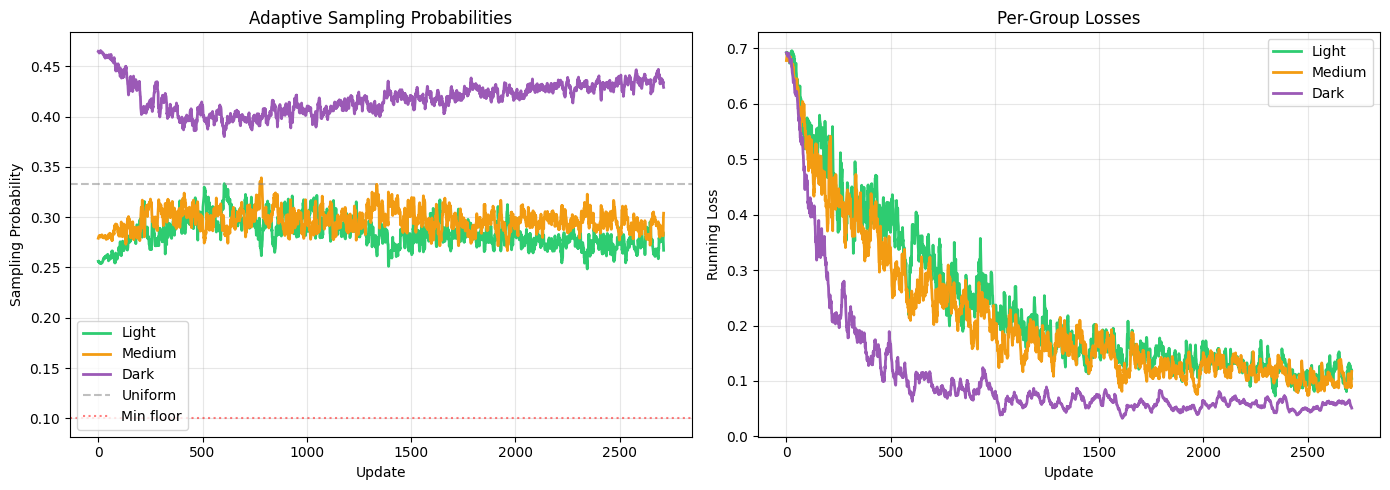

In [ ]:
# IMPORTANT: Pass train_df and val_df for group-aware augmentation to work
# The dataset will be recreated with per-group transforms
config = get_proposed_group_aug_config()
results = run_experiment(
    train_dataset, val_dataset, config, seed=SEED, device=device,
    train_df=train_df, val_df=val_df  # Required for group-aware augmentation
)
all_results[f'proposed_groupaug_seed{SEED}'] = results

save_experiment_results(results, f'proposed_groupaug_seed{SEED}', RESULTS_DIR)

# Plot adaptive sampler history
if results['adaptive_sampler']:
    results['adaptive_sampler'].plot_history(
        save_path=os.path.join(RESULTS_DIR, f'proposed_groupaug_seed{SEED}', 'sampler_history.png')
    )

## 4. Training Complete

Seed 123 experiments complete. Now aggregate with seed 42 results.

In [20]:
print("=" * 60)
print(f"SEED {SEED} TRAINING COMPLETE")
print("=" * 60)
print(f"\nModels saved to: {RESULTS_DIR}")
print(f"\nTrained models:")
for name in all_results.keys():
    print(f"  - {name}")

SEED 123 TRAINING COMPLETE

Models saved to: /content/drive/MyDrive/thesis/results

Trained models:
  - baseline_seed123
  - mixup_seed123
  - reweighted_seed123
  - focalloss_seed123
  - proposed_seed123


import json
from pathlib import Path

# Models to aggregate (including new group-aware augmentation)
MODELS = ['baseline', 'mixup', 'reweighted', 'focalloss', 'proposed', 'proposed_groupaug']
SEEDS = [42, 123]

def load_metrics(model_name, seed):
    """Load metrics.json for a specific model and seed."""
    metrics_path = Path(RESULTS_DIR) / f"{model_name}_seed{seed}" / "metrics.json"
    if metrics_path.exists():
        with open(metrics_path, 'r') as f:
            return json.load(f)
    else:
        print(f"Warning: {metrics_path} not found")
        return None

# Collect all metrics
all_metrics = {}
for model in MODELS:
    all_metrics[model] = {}
    for seed in SEEDS:
        metrics = load_metrics(model, seed)
        if metrics:
            all_metrics[model][seed] = metrics
            print(f"Loaded {model}_seed{seed}")
        else:
            print(f"Missing {model}_seed{seed}")

In [15]:
import json
from pathlib import Path

# Models to aggregate
MODELS = ['baseline', 'mixup', 'reweighted', 'focalloss', 'proposed', 'proposed_groupaug']
SEEDS = [42, 123]

def load_metrics(model_name, seed):
    """Load metrics.json for a specific model and seed."""
    metrics_path = Path(RESULTS_DIR) / f"{model_name}_seed{seed}" / "metrics.json"
    if metrics_path.exists():
        with open(metrics_path, 'r') as f:
            return json.load(f)
    else:
        print(f"Warning: {metrics_path} not found")
        return None

# Collect all metrics
all_metrics = {}
for model in MODELS:
    all_metrics[model] = {}
    for seed in SEEDS:
        metrics = load_metrics(model, seed)
        if metrics:
            all_metrics[model][seed] = metrics
            print(f"Loaded {model}_seed{seed}")
        else:
            print(f"Missing {model}_seed{seed}")

Loaded baseline_seed42
Loaded baseline_seed123
Loaded mixup_seed42
Loaded mixup_seed123
Loaded reweighted_seed42
Loaded reweighted_seed123
Loaded focalloss_seed42
Loaded focalloss_seed123
Loaded proposed_seed42
Loaded proposed_seed123
Loaded proposed_groupaug_seed42
Loaded proposed_groupaug_seed123


In [16]:
def aggregate_metrics(model_metrics):
    """Compute mean and std for a model across seeds."""
    seeds_data = list(model_metrics.values())
    if len(seeds_data) < 2:
        # Only one seed available
        return seeds_data[0] if seeds_data else None

    # Extract key metrics
    result = {
        'overall': {},
        'fairness': {}
    }

    # Overall metrics
    for key in ['accuracy', 'balanced_accuracy', 'f1_macro', 'f1_weighted', 'roc_auc']:
        values = [s['overall'].get(key) for s in seeds_data if s['overall'].get(key) is not None]
        if values:
            result['overall'][key] = {
                'mean': np.mean(values),
                'std': np.std(values),
                'values': values
            }

    # Fairness metrics
    for key in ['equal_opportunity_gap', 'equalized_odds_gap', 'f1_gap']:
        values = [s['fairness'].get(key) for s in seeds_data if s['fairness'].get(key) is not None]
        if values:
            result['fairness'][key] = {
                'mean': np.mean(values),
                'std': np.std(values),
                'values': values
            }

    # Per-group TPR
    result['fairness']['tpr_per_group'] = {}
    for group in ['Light', 'Medium', 'Dark']:
        values = [s['fairness']['tpr_per_group'].get(group) for s in seeds_data
                  if s['fairness']['tpr_per_group'].get(group) is not None]
        if values:
            result['fairness']['tpr_per_group'][group] = {
                'mean': np.mean(values),
                'std': np.std(values),
                'values': values
            }

    return result

# Aggregate all models
aggregated = {}
for model in MODELS:
    if all_metrics[model]:
        aggregated[model] = aggregate_metrics(all_metrics[model])

print("\nAggregation complete!")


Aggregation complete!


In [17]:
# Display aggregated results
print("=" * 70)
print("AGGREGATED RESULTS (Mean ± Std over 2 seeds)")
print("=" * 70)

# Build comparison table
rows = []
for model in MODELS:
    if model in aggregated:
        m = aggregated[model]
        row = {
            'Model': model.capitalize(),
            'Balanced Acc': f"{m['overall']['balanced_accuracy']['mean']:.4f} ± {m['overall']['balanced_accuracy']['std']:.4f}",
            'ROC-AUC': f"{m['overall']['roc_auc']['mean']:.4f} ± {m['overall']['roc_auc']['std']:.4f}" if 'roc_auc' in m['overall'] else 'N/A',
            'EO Gap': f"{m['fairness']['equal_opportunity_gap']['mean']:.4f} ± {m['fairness']['equal_opportunity_gap']['std']:.4f}",
            'TPR Dark': f"{m['fairness']['tpr_per_group']['Dark']['mean']:.4f} ± {m['fairness']['tpr_per_group']['Dark']['std']:.4f}",
        }
        rows.append(row)

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))

AGGREGATED RESULTS (Mean ± Std over 2 seeds)
            Model    Balanced Acc         ROC-AUC          EO Gap        TPR Dark
         Baseline 0.8382 ± 0.0194 0.9064 ± 0.0128 0.0573 ± 0.0256 0.7805 ± 0.0488
            Mixup 0.8561 ± 0.0061 0.9248 ± 0.0011 0.0400 ± 0.0272 0.7927 ± 0.0122
       Reweighted 0.8371 ± 0.0194 0.9065 ± 0.0126 0.0606 ± 0.0223 0.7805 ± 0.0488
        Focalloss 0.8221 ± 0.0089 0.9008 ± 0.0094 0.0839 ± 0.0122 0.7439 ± 0.0122
         Proposed 0.8643 ± 0.0011 0.9261 ± 0.0024 0.0552 ± 0.0037 0.8293 ± 0.0000
Proposed_groupaug 0.8544 ± 0.0022 0.9298 ± 0.0013 0.0901 ± 0.0458 0.7683 ± 0.0366


In [18]:
# Save aggregated results
aggregated_path = Path(RESULTS_DIR) / 'aggregated_results_2seeds.json'

# Convert numpy types to Python types for JSON serialization
def convert_to_serializable(obj):
    if isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_serializable(i) for i in obj]
    return obj

with open(aggregated_path, 'w') as f:
    json.dump(convert_to_serializable(aggregated), f, indent=2)

print(f"\nAggregated results saved to: {aggregated_path}")


Aggregated results saved to: /content/drive/MyDrive/thesis/results/aggregated_results_2seeds.json


In [19]:
# Save comparison table as CSV
comparison_path = Path(RESULTS_DIR) / 'multi_seed_comparison.csv'
comparison_df.to_csv(comparison_path, index=False)
print(f"Comparison table saved to: {comparison_path}")

Comparison table saved to: /content/drive/MyDrive/thesis/results/multi_seed_comparison.csv
